In [1]:
from functools import partial

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jaxpower import BinMesh2SpectrumPoles, FKPField, ParticleField, compute_fkp2_normalization, get_mesh_attrs
from jaxpower.mesh import _get_extent

from desiforwardwindow.convenience import fiducial_planck_2018, get_randoms
from desiforwardwindow.forward import get_AIC_foward_model, get_RIC_forward_model, mock_survey


Example of forward modelling the Y3 window, RIC and AIC for LRG SGC.

# Parameter choices

In [2]:
LOS = "local"
UNITARY_AMPLITUDE = True
BATCH_SIZE = 1

regression_maps = ['STARDENS','PSFSIZE_G','PSFSIZE_R','PSFSIZE_Z','GALDEPTH_G','GALDEPTH_R','GALDEPTH_Z','EBV_DIFF_GR','EBV_DIFF_RZ','HI'] # will need to create some of those, not stored

n_bins_AIC = 10 # template bins for the regression
n_bins_RIC = 1000 # distance bins for the shells in RIC

# Data preparation

## Read randoms from disk

In [3]:
tracer = "LRG"
positions, stored_weights = get_randoms(n_randoms=3, region="SGC", zrange=(0.4, 1.1), tracer=tracer, weight_type="default")
boxsize = jnp.array([8000.]*3)
cellsize=30.
data_size = positions.shape[0] // 2 # amount of data in the corresponding data catalog

stored_weights = stored_weights[0]

## Get systematics information

In [4]:
import fitsio
import healpy as hp
import LSS.common_tools as common
from numpy.lib.recfunctions import append_fields, structured_to_unstructured

debv = common.get_debv()

sys_tab = fitsio.read(f"/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/hpmaps/{tracer}_mapprops_healpix_nested_nside256_S.fits")

for col in regression_maps:
    if "DEPTH" in col:
        bnd = col.split("_")[-1]
        sys_tab[col] *= 10 ** (-0.4 * common.ext_coeff[bnd] * sys_tab["EBV"])
sys_tab = append_fields(sys_tab, names=["EBV_DIFF_" + ec for ec in ["GR", "RZ"]], data=[debv["EBV_DIFF_" + ec] for ec in ["GR", "RZ"]], usemask=False)

hpx_rand = hp.vec2pix(nside=256, x=positions[:, 0], y=positions[:, 1], z=positions[:, 2], nest=True)
template_values = structured_to_unstructured(sys_tab[regression_maps][hpx_rand]).astype(float)

del sys_tab, hpx_rand, debv

## Designate "data" and randoms

In [5]:
iseed = 42
seed = jax.random.key(iseed)
data_indices_in_randoms = jax.random.choice(key=seed, a=stored_weights.size, shape=[data_size], replace=False).astype(int)
mask_is_data = jnp.zeros_like(stored_weights, dtype=bool).at[data_indices_in_randoms].set(True)
mask_is_randoms = jnp.invert(mask_is_data)

Precompute everything that can be now. This should happen before creating any mesh due to incompability with sharding.

`get_AIC_foward_model` can be quite long due to some hefty operations on the randoms.

In [6]:
pos_min, pos_max = _get_extent(positions)
boxcenter = 0.5 * (pos_min + pos_max)

In [7]:
get_RIC_weights = get_RIC_forward_model(
    data_positions=positions[mask_is_data],
    randoms_positions=positions[mask_is_randoms],
    randoms_weights=stored_weights[mask_is_randoms],
    n_bins_RIC=n_bins_RIC,
    boxsize=boxsize,
    boxcenter=boxcenter,
)
get_AIC_weights = get_AIC_foward_model(
    data_weights=stored_weights[mask_is_data],
    randoms_weights=stored_weights[mask_is_randoms],
    template_values=template_values,
    mask_is_data=mask_is_data,
    n_bins=n_bins_AIC,
)


Starting from here, can shard

In [8]:
mattrs = get_mesh_attrs(positions, boxcenter=boxcenter, cellsize=cellsize, boxsize=boxsize, check=True)
# Can pre-paint the randoms, since they won't move. Can't paint data.
randoms = ParticleField(positions[~mask_is_data], weights=stored_weights[~mask_is_data], attrs=mattrs, exchange=True)
randoms_mesh = randoms.paint(resampler="tsc", interlacing=3, compensate=True)
randoms_shotnoise = (randoms.weights**2).sum()
data = ParticleField(positions[mask_is_data], weights=stored_weights[mask_is_data], attrs=mattrs, exchange=True)

del positions, stored_weights

## Details for P(k) computation

In [9]:
# To go from the mesh to the observed power spectrum
# Can always rebin ell = 2 to 0.002 later
binner = BinMesh2SpectrumPoles(randoms.attrs, edges={"step": 0.001}, ells=(0, 2, 4))

# Precompute the FKP power spectrum norm, without accounting for future data painting
FKP_field = FKPField(data=data, randoms=randoms)
fkp_norm = compute_fkp2_normalization(FKP_field, bin=binner, cellsize=10)
del FKP_field

# Fiducial theory

In [10]:
theory = fiducial_planck_2018(jnp.arange(0.0, mattrs.knyq.max(), 0.001)) # Stop at the selection's k_nyq

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/code/cosmoprimo/main/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


In [11]:
forward_model_pk = jax.jit(
    partial(
        mock_survey,
        theory=theory,
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
        binner=binner,
        randoms_shotnoise=randoms_shotnoise,
        fkp_norm=fkp_norm,
    ),
    static_argnames=["get_RIC_weights", "get_AIC_weights"],
)
# left: seed, data, randoms_mesh, get_AIC_weights, get_RIC_weights

In [12]:
pk_geo = forward_model_pk(seed=jax.random.key(123), data=data, randoms_mesh=randoms_mesh, get_RIC_weights=None, get_AIC_weights=None)
pk_RIC = forward_model_pk(seed=jax.random.key(123), data=data, randoms_mesh=randoms_mesh, get_RIC_weights=get_RIC_weights, get_AIC_weights=None)
pk_AIC = forward_model_pk(seed=jax.random.key(123), data=data, randoms_mesh=randoms_mesh, get_RIC_weights=None, get_AIC_weights=get_AIC_weights)
pk_ARIC = forward_model_pk(seed=jax.random.key(123), data=data, randoms_mesh=randoms_mesh, get_RIC_weights=get_RIC_weights, get_AIC_weights=get_AIC_weights)

Text(0.5, 0.98, 'Forward modeling on one LRG SGC-like realization')

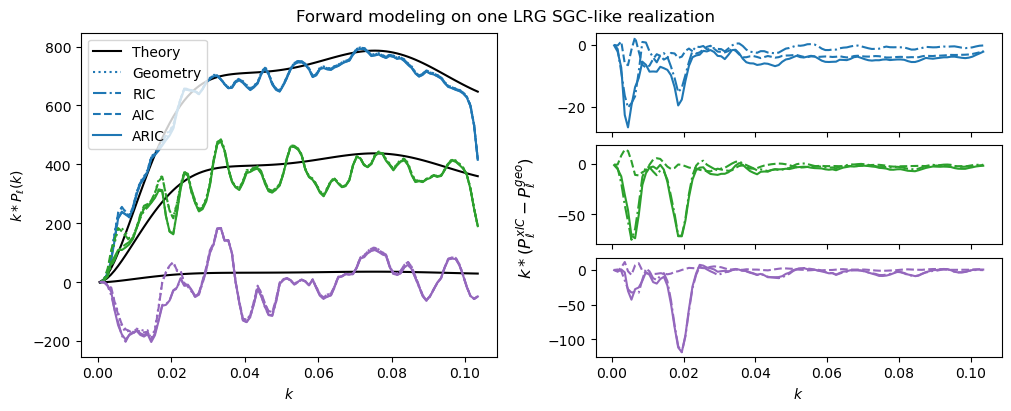

In [13]:
fig = plt.figure(layout='constrained', figsize=(10, 4))

figpk, figerr = fig.subfigures(1, 2)
axpk = figpk.add_subplot(111)

lax = figerr.subplots(3, 1, sharex=True)

for ell in [0, 2, 4]:
    pole = theory.get(ell)
    axpk.plot(pole.coords("k"), pole.coords("k")*pole.value(), color="k", label="Theory")

    color = f"C{ell}"
    for pk, label, ls in zip([pk_geo, pk_RIC, pk_AIC, pk_ARIC], ["Geometry", "RIC", "AIC", "ARIC"], [":", "-.", "--", "-"], strict=True):
        pole = pk.get(ell)
        axpk.plot(pole.coords("k"), pole.coords("k")*pole.value(), color=color, label=label, ls=ls)
    if ell == 0:
        axpk.legend()

    ax = lax[ell//2]
    pole_geo = pk_geo.get(ell)
    for pk, ls in zip([pk_RIC, pk_AIC, pk_ARIC], ["-.", "--", "-"], strict=True):
        pole = pk.get(ell)
        ax.plot(pole.coords("k"), pole.coords("k")*(pole.value() - pole_geo.value()), color=color, ls=ls)
axpk.set_xlabel(r"$k$")
axpk.set_ylabel(r"$k*P_\ell(k)$")
lax[-1].set_xlabel(r"$k$")
figerr.supylabel(r"$k*(P_\ell^{xIC} - P_\ell^{geo})$")
fig.suptitle("Forward modeling on one LRG SGC-like realization")


## More realizations

In [14]:
from lsstypes import mean, cov
from tqdm import tqdm
nreal = 40

In [15]:
pks_geo = [forward_model_pk(seed=jax.random.key(seed), data=data, randoms_mesh=randoms_mesh, get_RIC_weights=None, get_AIC_weights=None) for seed in tqdm(range(nreal))]
pks_RIC = [forward_model_pk(seed=jax.random.key(seed), data=data, randoms_mesh=randoms_mesh, get_RIC_weights=get_RIC_weights, get_AIC_weights=None) for seed in tqdm(range(nreal))]
pks_AIC = [forward_model_pk(seed=jax.random.key(seed), data=data, randoms_mesh=randoms_mesh, get_RIC_weights=None, get_AIC_weights=get_AIC_weights) for seed in tqdm(range(nreal))]
pks_ARIC = [forward_model_pk(seed=jax.random.key(seed), data=data, randoms_mesh=randoms_mesh, get_RIC_weights=get_RIC_weights, get_AIC_weights=get_AIC_weights) for seed in tqdm(range(nreal))]

100%|██████████| 40/40 [00:19<00:00,  2.10it/s]


In [16]:
pks_geo_mean = mean(pks_geo)
pks_geo_cov = cov(pks_geo)
pks_RIC_mean = mean(pks_RIC)
pks_RIC_cov = cov(pks_RIC)
pks_AIC_mean = mean(pks_AIC)
pks_AIC_cov = cov(pks_AIC)
pks_ARIC_mean = mean(pks_ARIC)
pks_ARIC_cov = cov(pks_ARIC)

## General comparison

Text(0.5, 0.98, 'Forward modeling on one LRG SGC-like realization')

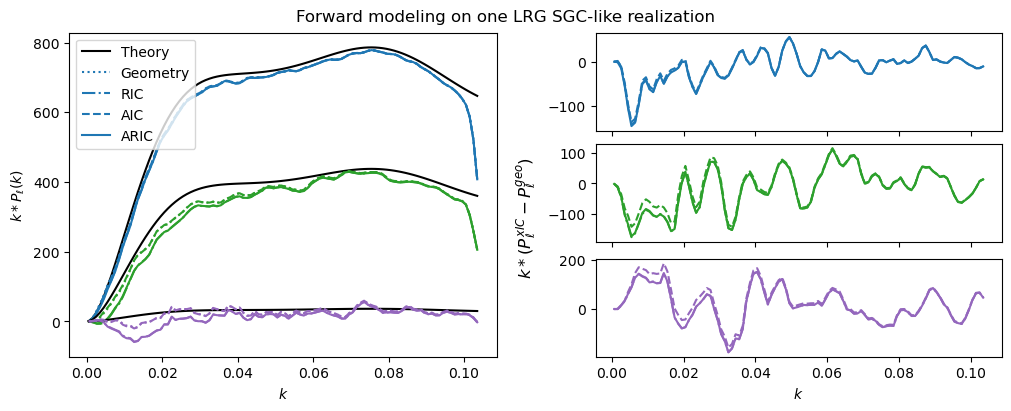

In [17]:
fig = plt.figure(layout='constrained', figsize=(10, 4))

figpk, figerr = fig.subfigures(1, 2)
axpk = figpk.add_subplot(111)

lax = figerr.subplots(3, 1, sharex=True)

for ell in [0, 2, 4]:
    pole = theory.get(ell)
    axpk.plot(pole.coords("k"), pole.coords("k")*pole.value(), color="k", label="Theory")

    color = f"C{ell}"
    for pk, cova, label, ls in zip([pks_geo_mean, pks_RIC_mean, pks_AIC_mean, pks_ARIC_mean], [pks_geo_cov, pks_RIC_cov, pks_AIC_cov, pks_ARIC_cov], ["Geometry", "RIC", "AIC", "ARIC"], [":", "-.", "--", "-"], strict=True):
        pole = pk.get(ell)
        std = cova.at.observable.get(ell).std()/jnp.sqrt(nreal)
        axpk.plot(pole.coords("k"), pole.coords("k")*pole.value(), color=color, label=label, ls=ls)
    if ell == 0:
        axpk.legend()

    ax = lax[ell//2]
    pole_geo = pk_geo.get(ell)
    for pk, ls in zip([pks_RIC_mean, pks_AIC_mean, pks_ARIC_mean], ["-.", "--", "-"], strict=True):
        pole = pk.get(ell)
        ax.plot(pole.coords("k"), pole.coords("k")*(pole.value() - pole_geo.value()), color=color, ls=ls)
axpk.set_xlabel(r"$k$")
axpk.set_ylabel(r"$k*P_\ell(k)$")
lax[-1].set_xlabel(r"$k$")
figerr.supylabel(r"$k*(P_\ell^{xIC} - P_\ell^{geo})$")
fig.suptitle("Forward modeling on one LRG SGC-like realization")

## Zoom on RIC

Text(0.5, 0.98, 'RIC forward modeling on one LRG SGC-like realization')

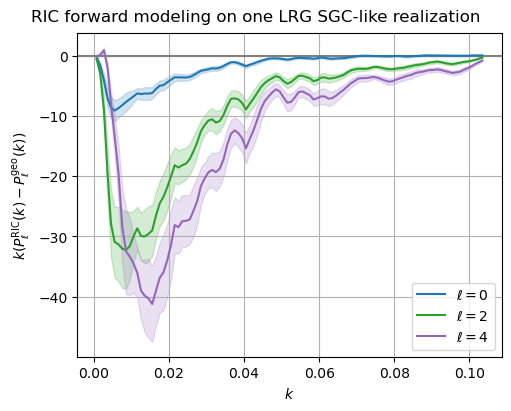

In [18]:
fig, ax = plt.subplots(layout='constrained', figsize=(5, 4))

ax.axhline(0, color="gray")
difference_RIC = [pk.clone(value=pk_RIC.value() - pk.value()) for pk, pk_RIC in zip(pks_geo, pks_RIC)]
difference_RIC_mean = mean(difference_RIC)
difference_RIC_cov = cov(difference_RIC)

for ell in [0, 2, 4]:
    color = f"C{ell}"
    difference = difference_RIC_mean.get(ell)
    std = difference_RIC_cov.at.observable.get(ell).std() / jnp.sqrt(nreal)
    ax.plot(difference.coords("k"), difference.coords("k")*difference.value(), color=color, label=f"$\ell={ell}$")
    ax.fill_between(difference.coords("k"), difference.coords("k")*(difference.value() - std), difference.coords("k")*(difference.value() + std), color=color, alpha=0.2)
ax.legend()
ax.grid()
ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$k(P_\ell^\mathrm{RIC}(k) - P_\ell^\mathrm{geo}(k))$")
fig.suptitle("RIC forward modeling on one LRG SGC-like realization")

## Zoom on AIC

Text(0.5, 0.98, 'AIC forward modeling on one LRG SGC-like realization')

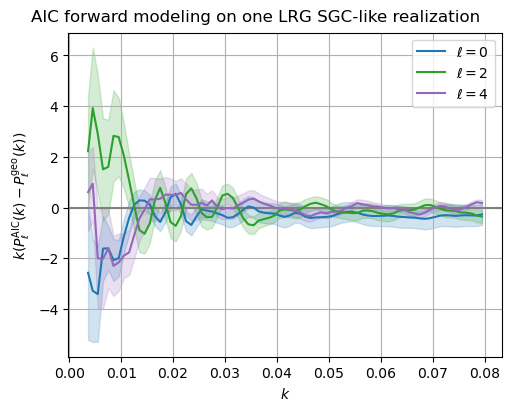

In [19]:
fig, ax = plt.subplots(layout='constrained', figsize=(5, 4))
ax.axhline(0, color="gray")
difference_AIC = [pk.clone(value=pk_AIC.value() - pk.value()) for pk, pk_AIC in zip(pks_geo, pks_AIC)]
difference_AIC_mean = mean(difference_AIC).select(k=(0.003, 0.08, 5))
difference_AIC_cov = cov(difference_AIC).at.observable.match(difference_AIC_mean)

for ell in [0, 2, 4]:
    color = f"C{ell}"
    difference = difference_AIC_mean.get(ell)
    std = difference_AIC_cov.at.observable.get(ell).std() / jnp.sqrt(nreal)
    ax.plot(difference.coords("k"), difference.coords("k")*difference.value(), color=color, label=f"$\ell={ell}$")
    ax.fill_between(difference.coords("k"), difference.coords("k")*(difference.value() - std), difference.coords("k")*(difference.value() + std), color=color, alpha=0.2)
ax.legend()
ax.grid()
ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$k(P_\ell^\mathrm{AIC}(k) - P_\ell^\mathrm{geo}(k))$")
fig.suptitle(f"AIC forward modeling on one {tracer} SGC-like realization")
